In [1]:
#activate venv: 
import pandas as pd
import time
#other requirements: sklearn, matplotlib, statsmodels

In [2]:
start=time.perf_counter()

In [3]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLRunningAveragesCalculator import FPLRunningAveragesCalculator

current_season = 20262027
current_gw = 0 #predictions from gw+1

start=time.perf_counter()

if __name__ == "__main__":
    #Run Database Creator
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Initialize the calculator
    calculator = FPLRunningAveragesCalculator(db_creator, current_season=current_season)
    
    # Define metrics to average
    metrics = ['minutes', 'total_points', 'team_elo', 'opp_team_elo',
        'goals_scored', 'assists', 'bonus', 'bps', 'clean_sheets', 'goals_conceded',
        'expected_goals', 'expected_assists', 'expected_goal_involvements',
        'expected_goals_conceded', 'cbi', 'defensive_contribution',
        'recoveries', 'tackles', 'saves'
    ]
    
    # Define interaction pairs
    interaction_pairs = [
        ('expected_goal_involvements', 'defensive_contribution'),
    ]
    
    # Calculate running averages
    df = calculator.calculate(
        metrics_to_average=metrics,
        window_sizes=[3, 5, 10],
        include_alltime=True,
        include_per_90=True,
        include_raw=True,
        include_elo_adjusted=True,
        include_squared_per_90=True,
        interaction_pairs=interaction_pairs
    )

    # Identify columns to exclude from forward filling (all fpl playergwdf columns) real life data columns
    exclude_cols = ['player_name_id', 'season', 'event',
                    'fixture', 'total_points', 'minutes',
                    'goals_scored', 'assists', 'team_elo', 'opp_team_elo',
                    'position', 'bonus', 'bps', 'clean_sheets',
                    'goals_conceded', 'was_home', 'expected_assists',
                    'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded',
                    'starts', 'team_name', 'opp_team_name',
                    'cbi','defensive_contribution','recoveries','tackles',
                    'saves']

    # Create a mask for rows to fill: current_season and event > current_gw
    mask = (df['season'] == current_season) & (df['event'] > current_gw)

    # Get columns to fill
    cols_to_fill = [col for col in df.columns if col not in exclude_cols]

    # Sort by player and event to ensure proper order
    df = df.sort_values(['season', 'player_name_id', 'event'])

    # Forward fill only for the masked rows
    df_filled = df.copy()

    for col in cols_to_fill:
        # Forward fill within each player group
        df_filled.loc[mask, col] = df_filled.groupby('player_name_id')[col].ffill()[mask]

    table_name = "playergw_transformed"
    db_creator.create_staging_table_then_insert_data(table_name, data=df_filled)
    playergw_transformed = db_creator.table_to_df(table_name=table_name)
    
    finish=time.perf_counter()
    print("playergw_transformed inserted into psql")
    print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
    print(playergw_transformed.info())
    

playergw_transformed inserted into psql
Finished in 83.57 minute(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229872 entries, 0 to 229871
Columns: 454 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(449), object(5)
memory usage: 796.2+ MB
None


In [4]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLPredictor import FPLPredictor

cbi_defcon_cols = [
    'cbi_at',
    'cbi_p90_at',
    'cbi_3',
    'cbi_p90_3',
    'cbi_elo_3',
    'cbi_elo_p90_3',
    'cbi_5',
    'cbi_p90_5',
    'cbi_elo_5',
    'cbi_elo_p90_5',
    'cbi_10',
    'cbi_p90_10',
    'cbi_elo_10',
    'cbi_elo_p90_10',
    'defensive_cont_at',
    'defensive_cont_p90_at',
    'defensive_cont_3',
    'defensive_cont_p90_3',
    'defensive_cont_elo_3',
    'defensive_cont_elo_p90_3',
    'defensive_cont_5',
    'defensive_cont_p90_5',
    'defensive_cont_elo_5',
    'defensive_cont_elo_p90_5',
    'defensive_cont_10',
    'defensive_cont_p90_10',
    'defensive_cont_elo_10',
    'defensive_cont_elo_p90_10',
    'saves_at',
    'saves_p90_at',
    'saves_3',
    'saves_p90_3',
    'saves_elo_3',
    'saves_elo_p90_3',
    'saves_5',
    'saves_p90_5',
    'saves_elo_5',
    'saves_elo_p90_5',
    'saves_10',
    'saves_p90_10',
    'saves_elo_10',
    'saves_elo_p90_10',
    'recoveries_at',
    'recoveries_p90_at',
    'recoveries_3',
    'recoveries_p90_3',
    'recoveries_elo_3',
    'recoveries_elo_p90_3',
    'recoveries_5',
    'recoveries_p90_5',
    'recoveries_elo_5',
    'recoveries_elo_p90_5',
    'recoveries_10',
    'recoveries_p90_10',
    'recoveries_elo_10',
    'recoveries_elo_p90_10',
    'tackles_at',
    'tackles_p90_at',
    'tackles_3',
    'tackles_p90_3',
    'tackles_elo_3',
    'tackles_elo_p90_3',
    'tackles_5',
    'tackles_p90_5',
    'tackles_elo_5',
    'tackles_elo_p90_5',
    'tackles_10',
    'tackles_p90_10',
    'tackles_elo_10',
    'tackles_elo_p90_10'
]

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Load df from sql
    df = db_creator.run_sql("""SELECT *
                            FROM playergw_transformed
                            """)
    print("=" * 80)
    print("Checking NaN Summary")
    print("=" * 80)

    temp_filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)
    temp_predictor = FPLPredictor(
        data=df[temp_filtered],
        target='expected_goals_per90',
        positions={'FWD', 'MID','DEF'},
        columns_to_drop=cbi_defcon_cols
    )
    nan_summary = temp_predictor.get_nan_summary()

Checking NaN Summary

NaN Summary for 310 potential features:
Total rows: 44356

Features with NaN values:
                                       feature  nan_count  nan_pct  non_null_count
                    defensive_cont_elo_p90sq_3      37378    84.27            6978
                        defensive_cont_p90sq_3      37378    84.27            6978
                        recoveries_elo_p90sq_3      37365    84.24            6991
                                   cbi_p90sq_3      37365    84.24            6991
                            recoveries_p90sq_3      37365    84.24            6991
                               cbi_elo_p90sq_3      37365    84.24            6991
                           tackles_elo_p90sq_3      37365    84.24            6991
                               tackles_p90sq_3      37365    84.24            6991
                    defensive_cont_elo_p90sq_5      37308    84.11            7048
                        defensive_cont_p90sq_5      37308    84

In [5]:
# #restricts to player_name_id who have >0 minutes in that season
# #model struggles to predict higher values, so maybe cut-off points at 10, or try log(points) as a depvar
# for each indepvar: filter outliers & standardize

In [6]:
# #Optimizing hyperparameters

# filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['expected_goals']>0)

# if __name__ == "__main__":

#     print("\n" + "=" * 80)
#     print("FWD xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)
    
#     FWD_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'FWD'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     FWD_xG_predictor.fit()
#     FWD_xG_predictor.plot_cv_results()
    
#     # Get best parameters in grid format
#     FWD_params_grid = FWD_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     FWD_xG_errors = FWD_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("MID xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     MID_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'MID'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300] # cannot be larger than sample size!
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     MID_xG_predictor.fit()
#     MID_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     MID_params_grid = MID_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     MID_xG_errors = MID_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("DEF xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     DEF_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'DEF'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     DEF_xG_predictor.fit()
#     DEF_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     DEF_params_grid = DEF_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     DEF_xG_errors = DEF_xG_predictor.get_largest_errors(return_full_data=True)


In [7]:
# print(FWD_params_grid)
# print(MID_params_grid)
# print(DEF_params_grid)

In [8]:
FWD_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
MID_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
DEF_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}

In [9]:
# target=expected_goals_per90, FWD_xG_predictor
# Cleaned df size: 2450/4170

# Performing GridSearchCV hyperparameter optimization...
# Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
# Cross-validation folds: 5
# Fitting 5 folds for each of 3 candidates, totalling 15 fits

# Best parameters found:
#   max_depth: 20
#   min_samples_split: 500
#   n_estimators: 200

# Best CV RMSE: 0.4231

# Training Set Performance:
# R² Score: 0.1823
# RMSE: 0.4056
# MAE: 0.2978

# Test Set Performance:
# R² Score: 0.1273
# RMSE: 0.4301
# MAE: 0.3197

In [10]:
mins_filter = (df['player_season_minutes_total']>100)&(df['minutes']>0)

if __name__ == "__main__":
    
    FWD_mins_predictor = FPLPredictor(
                data=df[mins_filter],
        target='minutes',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=50
        )
    FWD_mins_predictor.fit()
    # FWD_mins_predictor.plot_results()

    MID_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=50
        )
    MID_mins_predictor.fit()
    # MID_mins_predictor.plot_results()

    DEF_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=50
        )
    DEF_mins_predictor.fit()
    # DEF_mins_predictor.plot_results()

    GK_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10
        )
    GK_mins_predictor.fit()
    # GK_mins_predictor.plot_results()

Cleaned df size: 2909/8257

Training Set Performance:
R² Score: 0.8173
RMSE: 13.8738
MAE: 11.4462

Test Set Performance:
R² Score: 0.3881
RMSE: 26.2019
MAE: 21.6058

Top 20 Feature Importances:
                feature  importance
              minutes_3    0.272591
          minutes_elo_3    0.046606
   opp_team_elo_p90sq_3    0.045502
   opp_team_elo_p90sq_5    0.043090
  opp_team_elo_p90sq_10    0.009742
           opp_team_elo    0.008178
         opp_team_elo_3    0.008140
      team_elo_p90sq_10    0.007861
  opp_team_elo_p90sq_at    0.007368
      team_elo_p90sq_at    0.006901
               elo_diff    0.006764
goals_conceded_p90sq_at    0.006647
        opp_team_elo_10    0.006373
       team_elo_p90sq_3    0.006349
  clean_sheets_p90sq_at    0.006162
        xg_over_g_ratio    0.006004
         opp_team_elo_5    0.005924
  goals_conceded_elo_10    0.005884
       team_elo_p90sq_5    0.005851
                assists    0.005698
Cleaned df size: 10189/30676

Training Set Perform

In [11]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)&(df['total_points']<12)

if __name__ == "__main__":
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xG_predictor.fit()
    # FWD_xG_predictor.plot_results()

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xG_predictor.fit()
    # MID_xG_predictor.plot_results()
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xG_predictor.fit()
    # DEF_xG_predictor.plot_results()

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 2688/4748

Training Set Performance:
R² Score: 0.5640
RMSE: 0.2567
MAE: 0.2046

Test Set Performance:
R² Score: 0.0460
RMSE: 0.3883
MAE: 0.2897

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.060762
  goals_scored_p90sq_at    0.035452
           opp_team_elo    0.022507
        opp_team_elo_10    0.020469
     goals_scored_elo_3    0.019846
   opp_team_elo_p90sq_3    0.016119
        xg_over_g_ratio    0.014941
         opp_team_elo_5    0.014890
         opp_team_elo_3    0.014272
       assists_p90sq_at    0.014008
         bonus_p90sq_at    0.013494
       team_elo_p90sq_3    0.013470
               team_elo    0.012530
goals_conceded_p90sq_at    0.010192
      minutes_elo_p90_3    0.010161
     total_points_elo_3    0.010038
             assists_at    0.009743
       team_elo_p90sq_5    0.009390
      team_elo_p90sq_at    0.009299
          minutes_elo_3    0.009047
target=e

In [12]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_assists_per90, FWD_xA_predictor")
    FWD_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xA_predictor.fit()
    # FWD_xA_predictor.plot_results()

    print("target=expected_assists_per90, MID_xA_predictor")
    MID_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xA_predictor.fit()
    # MID_xA_predictor.plot_results()
    
    print("target=expected_assists_per90, DEF_xA_predictor")
    DEF_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xA_predictor.fit()
    # DEF_xA_predictor.plot_results()

target=expected_assists_per90, FWD_xA_predictor
Cleaned df size: 2887/5057

Training Set Performance:
R² Score: 0.6306
RMSE: 0.0748
MAE: 0.0502

Test Set Performance:
R² Score: -0.1251
RMSE: 0.1177
MAE: 0.0737

Top 20 Feature Importances:
                feature  importance
                assists    0.126860
         assists_elo_10    0.037254
         assists_p90_at    0.027713
   goals_conceded_elo_3    0.022572
           opp_team_elo    0.022236
               elo_diff    0.017442
  goals_conceded_elo_10    0.014552
    clean_sheets_elo_10    0.013908
   total_points_p90sq_3    0.012855
              assists_3    0.012201
         opp_team_elo_5    0.012102
       assists_p90sq_at    0.011258
         opp_team_elo_3    0.011220
clean_sheets_elo_p90_10    0.011018
        xg_over_g_ratio    0.010802
              bps_p90_5    0.010401
             assists_at    0.010381
goals_conceded_p90sq_at    0.010254
    clean_sheets_p90_10    0.010126
      goals_conceded_10    0.009541
targe

In [13]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_conceded_per90, FWD_xGC_predictor")
    FWD_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xGC_predictor.fit()
    # FWD_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, MID_xGC_predictor")
    MID_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xGC_predictor.fit()
    # MID_xGC_predictor.plot_results()
    
    print("target=expected_goals_conceded_per90, DEF_xGC_predictor")
    DEF_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xGC_predictor.fit()
    # DEF_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, GK_xGC_predictor")
    GK_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_xGC_predictor.fit()
    # GK_xGC_predictor.plot_results()

target=expected_goals_conceded_per90, FWD_xGC_predictor
Cleaned df size: 2887/5057

Training Set Performance:
R² Score: 0.6474
RMSE: 0.5247
MAE: 0.4259

Test Set Performance:
R² Score: 0.1376
RMSE: 0.9295
MAE: 0.7112

Top 20 Feature Importances:
                 feature  importance
                elo_diff    0.145763
            opp_team_elo    0.050231
         xg_over_g_ratio    0.024122
         opp_team_elo_10    0.023928
          opp_team_elo_5    0.015422
     minutes_elo_p90sq_3    0.013242
 goals_conceded_p90sq_10    0.013057
          opp_team_elo_3    0.012200
      minutes_elo_p90_10    0.010976
       team_elo_p90sq_at    0.010495
                team_elo    0.010231
 goals_conceded_p90sq_at    0.009930
        assists_p90sq_at    0.009502
    goals_conceded_elo_5    0.009402
              team_elo_5    0.009336
total_points_elo_p90sq_5    0.009251
   clean_sheets_p90sq_at    0.008980
              assists_at    0.008975
          assists_p90_at    0.008901
          bonu

In [14]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=bps_per90, FWD_bps_predictor")
    FWD_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90', # try: 'bonus_per90'
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_bps_predictor.fit()
    # FWD_bps_predictor.plot_results()

    print("target=bps_per90, MID_bps_predictor")
    MID_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_bps_predictor.fit()
    # MID_bps_predictor.plot_results()
    
    print("target=bps_per90, DEF_bps_predictor")
    DEF_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_bps_predictor.fit()
    # DEF_bps_predictor.plot_results()

    print("target=bps_per90, GK_bps_predictor")
    GK_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_bps_predictor.fit()
    # GK_bps_predictor.plot_results()

target=bps_per90, FWD_bps_predictor
Cleaned df size: 4147/5057

Training Set Performance:
R² Score: 0.5226
RMSE: 12.8122
MAE: 10.1535

Test Set Performance:
R² Score: 0.0503
RMSE: 17.2758
MAE: 13.4543

Top 20 Feature Importances:
                feature  importance
                assists    0.188846
               elo_diff    0.033691
           opp_team_elo    0.020233
         opp_team_elo_3    0.014778
           bonus_elo_10    0.013672
         bonus_p90sq_at    0.013557
        opp_team_elo_10    0.011542
goals_conceded_p90sq_at    0.011182
         opp_team_elo_5    0.010508
              bps_elo_3    0.009897
  clean_sheets_p90sq_at    0.009575
    minutes_elo_p90sq_3    0.009433
             team_elo_3    0.009101
  total_points_p90sq_at    0.008908
  goals_scored_p90sq_at    0.008700
                 bps_10    0.008659
    minutes_elo_p90sq_5    0.008327
     minutes_elo_p90_10    0.008142
        xg_over_g_ratio    0.007903
            bps_p90sq_5    0.007882
target=bps_per

c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the j


Training Set Performance:
R² Score: 0.4417
RMSE: 7.4856
MAE: 5.9811

Test Set Performance:
R² Score: 0.2075
RMSE: 8.8252
MAE: 6.9531

Top 20 Feature Importances:
                                   feature  importance
                                   assists    0.233587
                                  elo_diff    0.179237
xgoal_involvements_x_defensive_cont_p90_at    0.028629
                              opp_team_elo    0.024698
                           opp_team_elo_10    0.015181
                            opp_team_elo_3    0.014944
                            opp_team_elo_5    0.011024
                            bonus_p90sq_at    0.009744
                     clean_sheets_p90sq_at    0.009259
                               bps_p90sq_5    0.009184
                   goals_conceded_p90sq_at    0.008478
                              bps_p90sq_at    0.007863
                                 bps_p90_3    0.007041
                          bps_elo_p90sq_10    0.006776
            

c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the j

Cleaned df size: 4253/4495


c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the j


Training Set Performance:
R² Score: 0.5020
RMSE: 6.3277
MAE: 5.1805

Test Set Performance:
R² Score: 0.0635
RMSE: 8.6212
MAE: 6.7233

Top 20 Feature Importances:
                feature  importance
           opp_team_elo    0.032978
           bps_p90sq_10    0.029297
           bps_p90sq_at    0.026731
             bps_p90_10    0.026724
        opp_team_elo_10    0.021595
               elo_diff    0.019590
         saves_p90sq_at    0.017997
     saves_elo_p90sq_10    0.017568
  total_points_p90sq_10    0.017376
            bps_p90sq_5    0.016946
         saves_p90sq_10    0.016827
          saves_p90sq_5    0.015714
                assists    0.015639
       bps_elo_p90sq_10    0.015522
  total_points_p90sq_at    0.015003
  opp_team_elo_p90sq_at    0.014998
         opp_team_elo_3    0.014499
  opp_team_elo_p90sq_10    0.014443
goals_conceded_p90sq_at    0.014038
   opp_team_elo_p90sq_3    0.013286


c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the j

In [15]:
#shots saved
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=saves_per90, GK_saves_predictor")
    GK_saves_predictor = FPLPredictor(
        data=df[filtered],
        target='saves_per90',
        positions={'GK'},
        max_nan_pct=10)
    GK_saves_predictor.fit()
    # GK_saves_predictor.plot_results()

target=saves_per90, GK_saves_predictor
Cleaned df size: 4254/4514


c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the j


Training Set Performance:
R² Score: 0.5586
RMSE: 1.2843
MAE: 1.0363

Test Set Performance:
R² Score: 0.0428
RMSE: 1.9629
MAE: 1.5410

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.147498
               opp_team_elo    0.022892
      opp_team_elo_p90sq_at    0.016258
             saves_p90sq_at    0.016072
            opp_team_elo_10    0.014970
             opp_team_elo_5    0.014633
    goals_conceded_p90sq_at    0.014589
             saves_p90sq_10    0.013333
         saves_elo_p90sq_10    0.013266
               bps_p90sq_at    0.013158
      clean_sheets_p90sq_at    0.011976
          team_elo_p90sq_at    0.011632
             opp_team_elo_3    0.011581
             bonus_p90sq_at    0.011441
goals_conceded_elo_p90sq_10    0.011030
                   team_elo    0.010809
       opp_team_elo_p90sq_5    0.010737
          saves_elo_p90sq_3    0.010711
  total_points_elo_p90sq_10    0.010316
      opp_team_elo_p90sq_10    0.0096

c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the j

In [16]:
# >10 defcon (CBIT) for a defender
# >12 defcon (CBIT+R) for mid or fwd
filtered = (df['minutes']>30)&(df['player_season_minutes_total']>0)

if __name__ == "__main__":
    
    print("target=defensive_contribution_per90, FWD_defcon_predictor")
    FWD_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'FWD'},
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_defcon_predictor.fit()
    # FWD_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, MID_defcon_predictor")
    MID_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'MID'},
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_defcon_predictor.fit()
    # MID_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, DEF_defcon_predictor")
    DEF_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'DEF'},
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_defcon_predictor.fit()
    # DEF_defcon_predictor.plot_results()

target=defensive_contribution_per90, FWD_defcon_predictor
Cleaned df size: 855/5581


c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the j


Training Set Performance:
R² Score: 0.7750
RMSE: 1.3718
MAE: 1.0923

Test Set Performance:
R² Score: 0.0388
RMSE: 2.7167
MAE: 2.1116


c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the j


Top 20 Feature Importances:
                  feature  importance
               minutes_10    0.043372
     minutes_elo_p90sq_10    0.025418
           tackles_p90_at    0.022153
    clean_sheets_p90sq_at    0.019693
           opp_team_elo_5    0.018379
    goals_conceded_p90_10    0.018051
             opp_team_elo    0.015143
                 elo_diff    0.013804
          opp_team_elo_10    0.013414
               cbi_p90_at    0.013125
         team_elo_p90sq_5    0.013057
          xg_over_g_ratio    0.012912
               assists_at    0.012799
    goals_conceded_elo_10    0.012712
  goals_conceded_p90sq_at    0.012398
goals_conceded_elo_p90_10    0.012111
        recoveries_p90_at    0.011747
           opp_team_elo_3    0.011620
        goals_conceded_10    0.011541
     opp_team_elo_p90sq_3    0.011248
target=defensive_contribution_per90, MID_defcon_predictor
Cleaned df size: 3714/22874


c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the j


Training Set Performance:
R² Score: 0.6750
RMSE: 2.4089
MAE: 1.9344

Test Set Performance:
R² Score: 0.1721
RMSE: 3.8565
MAE: 2.9766

Top 20 Feature Importances:
                                   feature  importance
                            assists_p90_at    0.084831
                                cbi_p90_at    0.061008
                     goals_scored_p90sq_at    0.051913
                   goals_conceded_p90sq_at    0.030393
                                assists_at    0.024285
                          assists_p90sq_at    0.022364
                            tackles_p90_at    0.018852
                              bps_p90sq_at    0.018350
xgoal_involvements_x_defensive_cont_p90_at    0.016638
                          team_elo_p90sq_3    0.012810
                     clean_sheets_p90sq_at    0.012650
                         recoveries_p90_at    0.012446
                     total_points_p90sq_at    0.011531
                                  elo_diff    0.010228
            

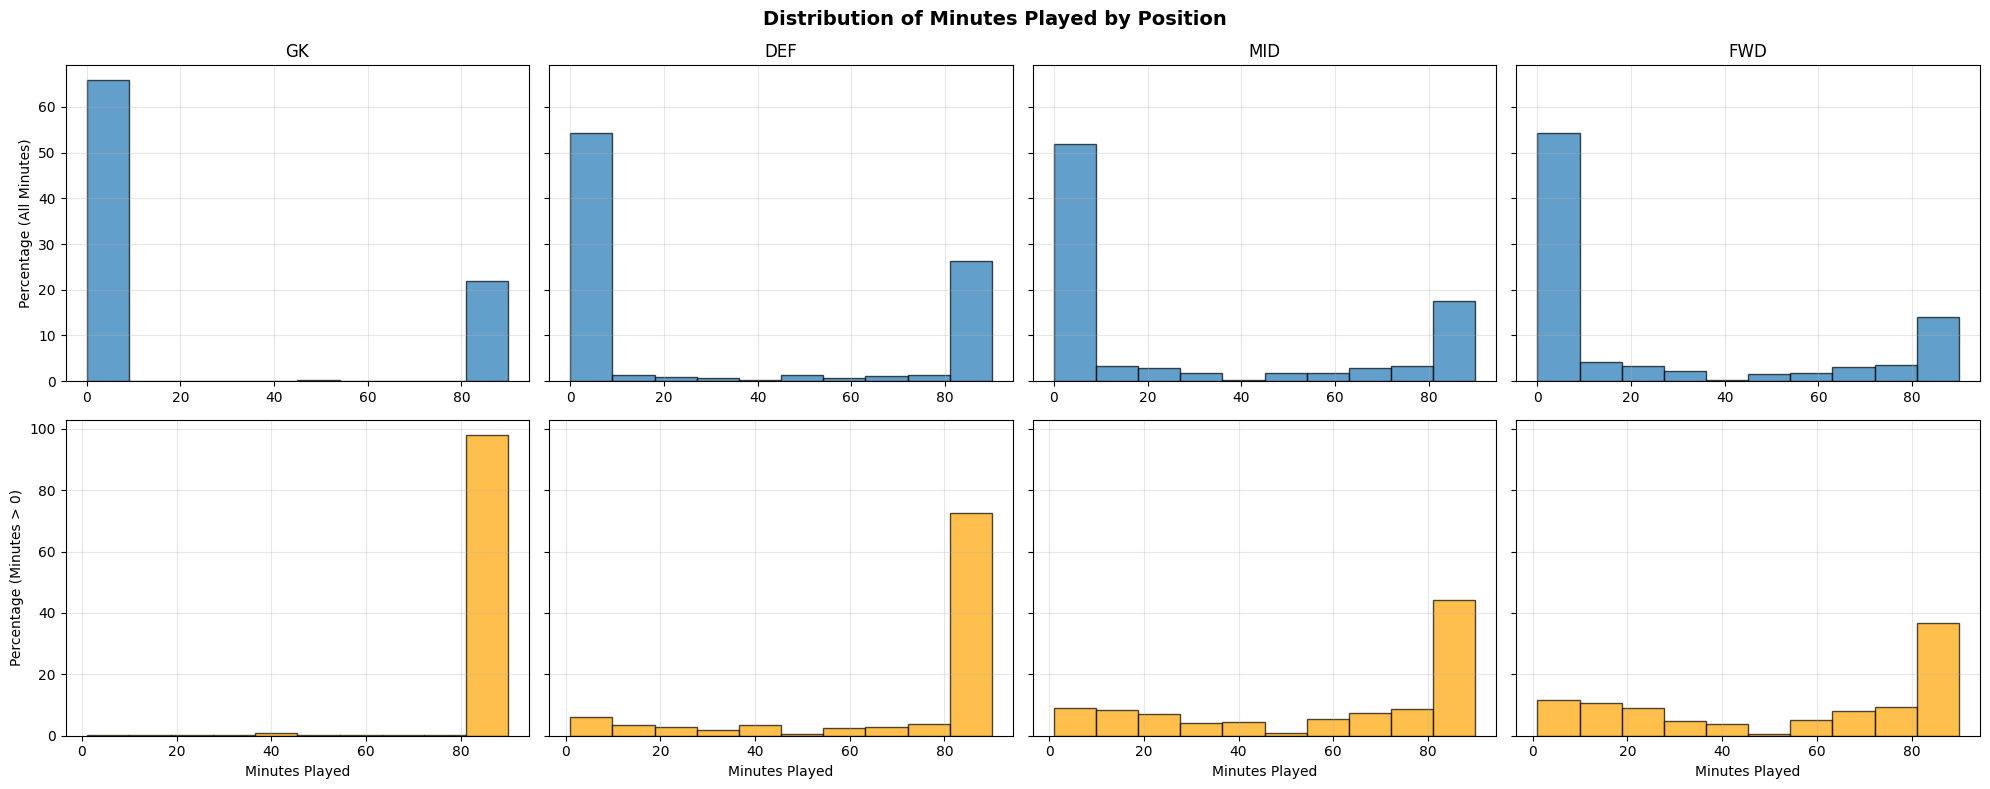

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter for specific positions
positions = ['GK', 'DEF', 'MID', 'FWD']
n_positions = len(positions)

# Create subplots with 2 rows
fig, axes = plt.subplots(2, n_positions, figsize=(5*n_positions, 8), sharey='row')

# Row 1: All data
for i, position in enumerate(positions):
    position_minutes = df[df['position'] == position]['minutes']
    axes[0, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, 
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[0, i].set_title(position)
    axes[0, i].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Percentage (All Minutes)')

# Row 2: Minutes > 0
for i, position in enumerate(positions):
    position_minutes = df[(df['position'] == position) & (df['minutes'] > 0)]['minutes']
    axes[1, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, color='orange',
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[1, i].set_xlabel('Minutes Played')
    axes[1, i].grid(True, alpha=0.3)

axes[1, 0].set_ylabel('Percentage (Minutes > 0)')

plt.suptitle('Distribution of Minutes Played by Position', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Goals conceded per 90
Estimated λ (mean goals per match): 1.371


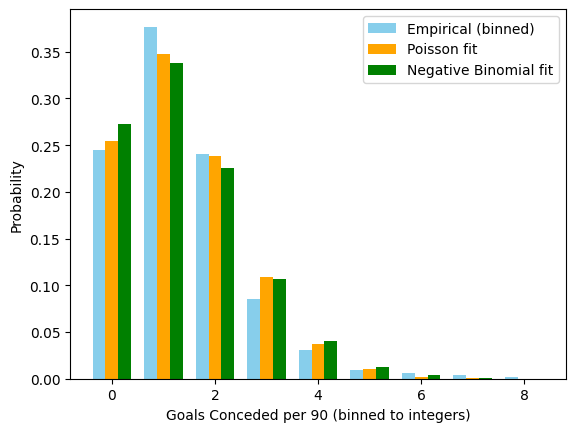

Mean: 1.362, Variance: 1.494
Overdispersion ratio (Var/Mean): 1.097
✅ Poisson assumption looks reasonable.
P(X < 1 goal) = 0.254


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Goals conceded per 90")

# Compute xGC per 90
data = df.copy()
data['xgc_p90'] = (data['expected_goals_conceded'] / data['minutes']) * 90

# Filter to reasonable samples
data = data[(data['minutes'] > 0) & (data['xgc_p90'] < 8)]['xgc_p90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean goals per match): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Goals Conceded per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")

# --- Example probability ---
p_less_than_1 = poisson.cdf(0, mu=lambda_hat)
print(f"P(X < 1 goal) = {p_less_than_1:.3f}")


Mids & Forwards
Estimated λ (mean defcon per 90): 8.131


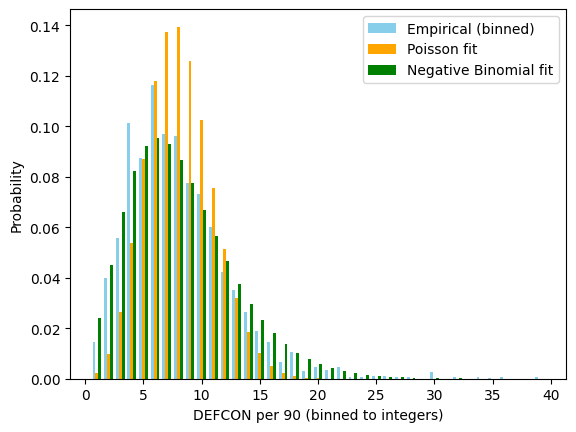

Mean: 8.123, Variance: 20.899
Overdispersion ratio (Var/Mean): 2.573
⚠️ Likely overdispersed → Negative Binomial may fit better.


In [19]:
#Test if defcon_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Mids & Forwards")

# Filter to reasonable samples
data = df[(df['minutes'] > 0)
          & (df['defensive_contribution_per90'] > 0) 
          & (df['defensive_contribution_per90'] < 40)
          & (df['position'].isin(['DEF']))]['defensive_contribution_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('DEFCON per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


GK saves per 90
Estimated λ (mean saves per 90): 3.194


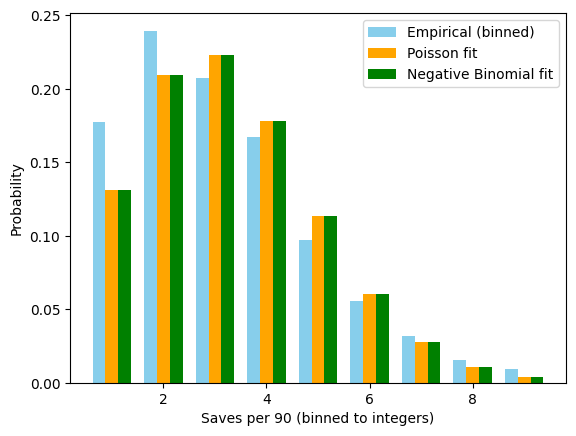

Mean: 3.194, Variance: 3.194
Overdispersion ratio (Var/Mean): 1.000
✅ Poisson assumption looks reasonable.


In [20]:
#Test if saves_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("GK saves per 90")

# Filter to reasonable samples
data = df[#(df['minutes'] > 0)
          (df['saves_per90'] > 0) 
          & (df['saves_per90'] < 10)
          & (df['position'].isin(['GK']))]['saves_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean saves per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Saves per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


In [21]:
#Create the data which the prediction data should be added to
prediction_data = df[(df['season']==current_season)
                     &(df['event']>=current_gw+1)]

In [22]:
def predict_target_vectorized(df, model_dict, col_name):
    preds = []
    
    for pos, model in model_dict.items():
        subset = df[df['position'] == pos]
        if not subset.empty:
            pos_preds = model.predict_new(subset)
            temp = subset.copy()
            temp[col_name] = pos_preds
            preds.append(temp)
    
    if not preds:
        # If no positions matched at all
        return pd.Series(index=df.index, dtype=float)
    
    result = pd.concat(preds)
    
    # Safely align back to original DataFrame
    output = pd.Series(index=df.index, dtype=float)
    output.loc[result.index] = result[col_name]
    return output

In [23]:
target_col_name = 'mins_pred'
mins_model_dict = {'FWD': FWD_mins_predictor, 'MID': MID_mins_predictor, 'DEF': DEF_mins_predictor, 'GK': GK_mins_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_364\2521843321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)


count    22192.000000
mean        62.362170
std         19.953734
min         12.639186
25%         45.645907
50%         60.318817
75%         84.608276
max         89.915476
Name: mins_pred, dtype: float64

In [24]:
target_col_name = 'xgp90_pred'
xg_model_dict = {'FWD': FWD_xG_predictor, 'MID': MID_xG_predictor, 'DEF': DEF_xG_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_364\365369552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)


count    19760.000000
mean         0.137204
std          0.123774
min          0.024254
25%          0.048567
50%          0.083460
75%          0.168260
max          0.713716
Name: xgp90_pred, dtype: float64

In [25]:
target_col_name = 'xap90_pred'
xA_model_dict = {'FWD': FWD_xA_predictor, 'MID': MID_xA_predictor, 'DEF': DEF_xA_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_364\4144355699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)


count    19760.000000
mean         0.072472
std          0.051464
min          0.020768
25%          0.037604
50%          0.060227
75%          0.092393
max          0.482955
Name: xap90_pred, dtype: float64

In [26]:
target_col_name = 'xgcp90_pred'
xGC_model_dict = {'FWD': FWD_xGC_predictor, 'MID': MID_xGC_predictor, 'DEF': DEF_xGC_predictor, 'GK':GK_xGC_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_364\682035545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)


count    22192.000000
mean         1.437732
std          0.313612
min          0.489528
25%          1.249318
50%          1.384214
75%          1.616052
max          3.158912
Name: xgcp90_pred, dtype: float64

In [27]:
target_col_name = 'xbpsp90_pred'
bps_model_dict = {'FWD': FWD_bps_predictor, 'MID': MID_bps_predictor, 'DEF': DEF_bps_predictor, 'GK':GK_bps_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_364\3051138591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)


count    22192.000000
mean        14.541987
std          2.980501
min          5.895956
25%         12.567059
50%         14.240775
75%         16.485599
max         33.939993
Name: xbpsp90_pred, dtype: float64

                                 OLS Regression Results                                
Dep. Variable:                  bonus   R-squared (uncentered):                   0.448
Model:                            OLS   Adj. R-squared (uncentered):              0.448
Method:                 Least Squares   F-statistic:                          3.794e+04
Date:                Thu, 13 Aug 2026   Prob (F-statistic):                        0.00
Time:                        23:49:41   Log-Likelihood:                         -44106.
No. Observations:               46768   AIC:                                  8.821e+04
Df Residuals:                   46767   BIC:                                  8.822e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

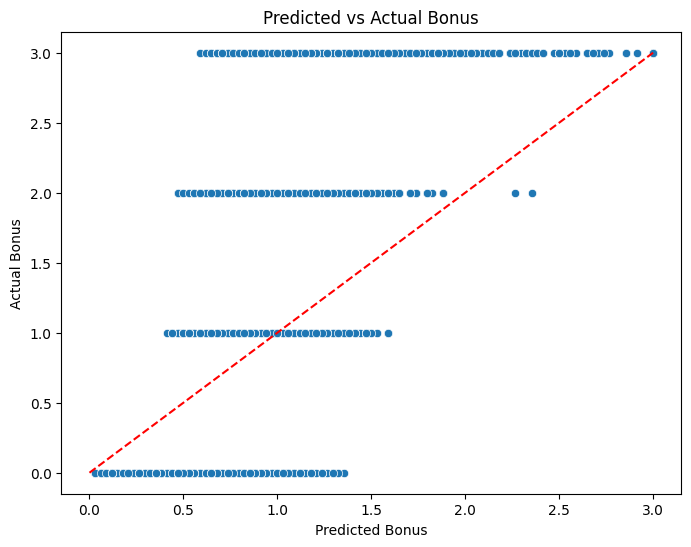

Actual Bonus       0.0       1.0       2.0       3.0
Position                                            
AM                 NaN       NaN       NaN       NaN
DEF           0.459324  0.227978  1.105632  1.942520
FWD           0.330644  0.200042  1.044911  1.710679
GK            0.488289  0.243133  1.113235  2.006779
GKP                NaN       NaN       NaN       NaN
MID           0.398403  0.244019  1.049373  1.825297


C:\Users\Chris\AppData\Local\Temp\ipykernel_364\3541705010.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))


In [28]:
# Generalize the relationship between bps & bonus points
import statsmodels.formula.api as smf
dfb=df.copy()
filtered = (dfb['minutes']>45) & (dfb['bonus']>=0) & (dfb['bps']>0) & (dfb['position'].isin(['GK','DEF','MID','FWD']))
# df['bonus_sq'] = df['bonus']**2

model = smf.ols('bonus ~ bps -1', data=dfb[filtered]).fit()
print(model.summary())

dfb['bonus_pred'] = model.predict(dfb[filtered])
dfb['bonus_pred'] = np.clip(dfb['bonus_pred'], 0, 3) # clip prediction to 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bonus_pred', y='bonus', data=dfb)
plt.plot([dfb['bonus'].min(), dfb['bonus'].max()],
         [dfb['bonus'].min(), dfb['bonus'].max()],
         color='red', linestyle='--')  # 45-degree line
plt.xlabel('Predicted Bonus')
plt.ylabel('Actual Bonus')
plt.title('Predicted vs Actual Bonus')
plt.show()

import pandas as pd
import numpy as np

# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Group by position and actual bonus, then calculate RMSE
rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))

# Convert to DataFrame
rmse_table = rmse_table.reset_index()
rmse_table.columns = ['Position', 'Actual Bonus', 'RMSE']

pivot_rmse = rmse_table.pivot(index='Position', columns='Actual Bonus', values='RMSE')
print(pivot_rmse)


In [29]:
#Add bonus prediction to data
prediction_data['bonus_pred'] = model.predict(prediction_data)
print("bonus_pred added to prediction data")

bonus_pred added to prediction data


C:\Users\Chris\AppData\Local\Temp\ipykernel_364\2545047019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['bonus_pred'] = model.predict(prediction_data)


In [30]:
target_col_name = 'xsavesp90_pred'
saves_model_dict = {'GK':GK_saves_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_364\803536942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)


count    2432.000000
mean        3.157032
std         0.586779
min         1.461465
25%         2.709894
50%         3.047965
75%         3.456489
max         5.204602
Name: xsavesp90_pred, dtype: float64

In [31]:
target_col_name = 'xdefconp90_pred'
defcon_model_dict = {'FWD': FWD_defcon_predictor, 'MID': MID_defcon_predictor, 'DEF': DEF_defcon_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_364\2777375241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)


count    19760.000000
mean         7.329694
std          1.838888
min          2.420711
25%          6.603882
50%          7.295943
75%          8.492767
max         18.927749
Name: xdefconp90_pred, dtype: float64

In [32]:
prediction_data[
    (prediction_data['event']==current_gw+1)
    &(prediction_data['mins_pred']>0)
    ][["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]].sort_values(by='xgp90_pred',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
79127,Mohammed Kudus,512.0,64.0,Spurs,MID,20262027.0,1.0,Brentford,1066.574657,43.857124,0.696253,0.229723,1.657199
71061,Gabriel Fernando de Jesus,27.0,64.0,Arsenal,FWD,20262027.0,1.0,Coventry City,1000.000000,56.333938,0.692689,0.055515,1.069287
78038,Marcus Rashford,429.0,70.0,Man Utd,MID,20262027.0,1.0,Hull City,1000.000000,56.858432,0.638835,0.238430,1.259203
74497,Joe Gelhardt,340.0,45.0,Leeds,MID,20262027.0,1.0,Nott'm Forest,1070.967897,36.442784,0.618640,0.211787,1.960414
69798,Ellis Simms,195.0,45.0,Coventry City,FWD,20262027.0,1.0,Arsenal,1225.024109,32.905620,0.615096,0.141150,1.992385
75452,Justin Kluivert,70.0,69.0,Bournemouth,MID,20262027.0,1.0,Man City,1210.175966,28.001009,0.592415,0.172324,2.069555
82919,Romain Esse,216.0,47.0,Crystal Palace,MID,20262027.0,1.0,Everton,1049.802533,34.724403,0.547351,0.115922,1.774425
70056,Eddie Nketiah,224.0,54.0,Crystal Palace,FWD,20262027.0,1.0,Everton,1049.802533,43.980333,0.545038,0.146836,1.308146
69720,Dominic Solanke-Mitchell,526.0,71.0,Spurs,FWD,20262027.0,1.0,Brentford,1066.574657,55.245733,0.539360,0.152210,1.522557
80317,Stefanos Tzimas,137.0,52.0,Brighton,FWD,20262027.0,1.0,Aston Villa,1132.336710,42.692109,0.533965,0.163575,1.374948


In [33]:
# -----------------------------------------------------------------------
# Build per-player overperformance factors from ALL historical data in df
# -----------------------------------------------------------------------
# stat_pairs: (actual_column, expected_column, output_key)
#   'xg' key  → will be applied to xgp90_pred
#   'xa' key  → will be applied to xap90_pred

from FPLStatOverperformanceAnalyzer import (
    FPLStatOverperformanceAnalyzer,
    build_player_adjustments,
    apply_adjustments,
)

overperf_adjustments = build_player_adjustments(
    df.dropna(subset=['expected_goals','expected_assists']), # only consider rows with xG and xA for adjustment calculations
    stat_pairs=[
        ('goals_scored',  'expected_goals',   'xg'),
        ('assists',       'expected_assists',  'xa')],
    taper_k_90s=15.0, # 15 90s needed for 50% credibility (50% observed & 50% prior(1))
    only_if_significant=True, # only adjust if p < 0.05
    min_xstat=2.0, # need ≥2 cumulative xG/xA to run test
)

print(f"Computed adjustments for {len(overperf_adjustments)} players")

# Apply factors to prediction_data
#   - Saves original columns as xgp90_pred_raw / xap90_pred_raw
#   - Adds xg_overperf_factor / xa_overperf_factor columns for audit
prediction_data = apply_adjustments(
    prediction_data,
    overperf_adjustments,
    col_map={
        'xg': 'xgp90_pred',
        'xa': 'xap90_pred',
    },
)

# Show the adjustment for the next gameweek's top players
print(f"\nNext GW{current_gw + 1} Top Players with Overperformance Factors:")
(
    prediction_data[prediction_data['event'] == current_gw + 1]
    [['player_name_id','position', 'xg_overperf_factor', 'xa_overperf_factor',
      'xgp90_pred_raw', 'xgp90_pred',
      'xap90_pred_raw', 'xap90_pred']].groupby('player_name_id').agg({'position': 'first', 'xg_overperf_factor': 'mean', 'xa_overperf_factor': 'mean',
                                                                      'xgp90_pred_raw': 'mean', 'xgp90_pred': 'mean', 'xap90_pred_raw': 'mean', 'xap90_pred': 'mean'})
    .sort_values('xg_overperf_factor', ascending=False)
    .head(30))

Computed adjustments for 1237 players

Next GW1 Top Players with Overperformance Factors:


c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\FPLStatOverperformanceAnalyzer.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[f"{col}_raw"]             = prediction_data[col].copy()
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\FPLStatOverperformanceAnalyzer.py:110: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[col]                      = prediction_data[col] * factors
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\FPLStatOv

,position,xg_overperf_factor,xa_overperf_factor,xgp90_pred_raw,xgp90_pred,xap90_pred_raw,xap90_pred
player_name_id,,,,,,,
Ryan Sessegnon,DEF,2.101780,1.000000,0.097351,0.204610,0.073027,0.073027
Mathias Jensen,MID,2.016493,1.000000,0.102885,0.207467,0.100850,0.100850
Callum Hudson-Odoi,MID,1.825412,1.000000,0.192260,0.350954,0.097940,0.097940
Phil Foden,MID,1.730045,1.000000,0.198784,0.343905,0.146670,0.146670
Declan Rice,MID,1.607111,1.403110,0.132489,0.212925,0.185427,0.260174
Harvey Barnes,MID,1.401158,1.000000,0.207589,0.290865,0.099252,0.099252
Antoine Semenyo,MID,1.382869,1.642661,0.188890,0.261210,0.129724,0.213093
Taiwo Awoniyi,FWD,1.358401,1.000000,0.301538,0.409609,0.049666,0.049666
Erling Haaland,FWD,1.165356,3.141298,0.363765,0.423916,0.054943,0.172592


In [34]:
import pandas as pd
from scipy.stats import nbinom

def calculate_negbinom_parameters(position_list, df):

    # 1. Calculate mean and variance
    filtered = (df['minutes'] > 0) & (df['defensive_contribution_per90'] > 0) & (df['defensive_contribution_per90'] < 40) & (df['position'].isin(position_list))
    mean = df[filtered]['defensive_contribution_per90'].mean()
    variance = df[filtered]['defensive_contribution_per90'].var()
    # r = number of successes
    r = (mean**2) / (variance - mean)
    # p = success probability
    p = r / (r + mean)
    return r,p

In [35]:
from scipy.stats import poisson
import numpy as np

def expected_score(mu, max_events=10, rule=None, points_per_n=None, points_value=None):
    """
    Calculate the expected score given an average event rate (mu)
    using a Poisson model.

    Parameters
    ----------
    mu : float
        Expected number of events (e.g., goals conceded, shots saved).
    max_events : int
        Maximum number of discrete events to sum over.
    rule : callable, optional
        Function that maps event count -> points. Example: lambda k: -np.floor(k / 2)
    points_per_n : int, optional
        For simple rules: number of events required for one point (e.g. 3 shots saved = 1 pt)
    points_value : float, optional
        Value of that one point (e.g. +1 for shots saved, -1 for goals conceded)

    Returns
    -------
    float
        Expected points based on Poisson-distributed event counts.
    """
    array = np.arange(0, max_events + 1)
    probs = poisson.pmf(array, mu)

    if rule is not None:
        scores = np.array([rule(k) for k in array])
    elif points_per_n is not None and points_value is not None:
        # General simple rule: 1 point_value for every n events
        scores = np.floor(array / points_per_n) * points_value
    else:
        raise ValueError("You must provide either a rule function or both points_per_n and points_value.")

    return np.sum(scores * probs)


In [36]:
from scipy.stats import norm
import numpy as np

scoring_dict = {
    "FWD": {'xgp90_pred': 4, 'xap90_pred': 3, 'xgcp90_pred': 0, 'xgc_ss':0, 'defcon':2},
    "MID": {'xgp90_pred': 5, 'xap90_pred': 3, 'xgcp90_pred': 1, 'xgc_ss':0, 'defcon':2},
    "DEF": {'xgp90_pred': 6, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2},
    "GK":  {'xgp90_pred': 10, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2}
}

def scoring(x, scoring_dict, points_type, negbinom_rp_dict=None):
    mins_factor = x['mins_pred']/90
    if points_type == 'mins':
        if pd.isna(x['mins_pred']):
            return 0
        elif x['mins_pred'] > 0:
            return 1 + 1 / (1 + np.exp(-(x['mins_pred'] - 60) / 10)) #smooth logistic approximation from 1 to 2 points, 10 is a scale factor
        
    if points_type == 'goals':
        goals_points = mins_factor * x['xgp90_pred'] * scoring_dict[x['position']]['xgp90_pred']
        return goals_points
    if points_type == 'assists':
        assist_points = mins_factor * x['xap90_pred'] * scoring_dict[x['position']]['xap90_pred']
        return assist_points
    if points_type == 'clean_sheets':
        p_less_than_1 = poisson.cdf(0, mu=x['xgcp90_pred'])
        cs_points = p_less_than_1 * scoring_dict[x['position']]['xgcp90_pred']
        return cs_points
    
    if points_type == 'shots_saved': 
        if x['position'] == 'GK':
            saves_points = expected_score(mu=x['xsavesp90_pred'],  # expected shots saved per 90
                                   max_events=15,
                                   points_per_n=3, #for every 3 shots saved
                                   points_value=1) #scores 1 point
            return saves_points
        else:
            return 0
        
    if points_type == 'goals_conceded':
        if x['position'] in ['DEF','GK']:
            gc_points = expected_score(mu=x['xgcp90_pred'], 
                                   max_events=10, 
                                   points_per_n=2, #for every 2 goals conceded 
                                   points_value=-1) #scores -1 points 
            return gc_points
        else:
            return 0

    if points_type == 'defcon':
        pos = x['position']
        if pos in ['MID','FWD']:
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 12
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        elif pos == 'DEF':
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 10
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        else: return 0

    if points_type == 'bonus':
        return x['xbpsp90_pred']*0.0294 # ols regression coefficient

point_cols = [
    'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
    'xpoints_shots_saved', 'xpoints_goals_conceded', 'xpoints_defcon', 'xpoints_bonus', 'xpoints'
]

if prediction_data.empty: # gw38 there are no future predictions.
    for col in point_cols:
        prediction_data[col] = pd.Series(dtype=float)
else:
    prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
    prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
    prediction_data['xpoints_assists'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='assists'), axis=1)
    prediction_data['xpoints_clean_sheets'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='clean_sheets'), axis=1)

    prediction_data['xpoints_shots_saved'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='shots_saved'), axis=1)
    prediction_data['xpoints_goals_conceded'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals_conceded'), axis=1)

    def_r,def_p = calculate_negbinom_parameters(['DEF'], df)
    mid_r,mid_p = calculate_negbinom_parameters(['MID'], df)
    fwd_r,fwd_p = calculate_negbinom_parameters(['FWD'], df)
    rp_dict = {'DEF':{'r':def_r,'p':def_p},'MID':{'r':mid_r,'p':mid_p},'FWD':{'r':fwd_r,'p':fwd_p}}
    prediction_data['xpoints_defcon'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='defcon', negbinom_rp_dict=rp_dict), axis=1)
    prediction_data['xpoints_bonus'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='bonus'), axis=1)

    prediction_data['xpoints'] = prediction_data[['xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
                                              'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus']].sum(axis=1, skipna=True)

C:\Users\Chris\AppData\Local\Temp\ipykernel_364\3160191609.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_364\3160191609.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_36

In [37]:
predictions = prediction_data[['player_name_id', 'team_name','team_elo','element','position','opp_team_name','opp_team_elo', 'season', 'value', 'event','fixture',
                       'mins_pred', 'xgp90_pred', 'xap90_pred', 'xgcp90_pred',
                       'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xg_overperf_factor', 'xa_overperf_factor','xpoints_clean_sheets','xpoints_shots_saved',
                       'xpoints_goals_conceded','xpoints_defcon','xpoints_bonus','xpoints']]
fixture_predictions = predictions.copy()  # keep per-fixture detail
# Existing per-fixture xpoints are computed above
# Now aggregate to gameweek level by summing across fixtures within each event

predictions_by_gw = predictions.groupby(
    ['player_name_id', 'element', 'team_name', 'position', 'season', 'event', 'value'],
    as_index=False,
    dropna=False
).agg(
    # descriptive
    team_name=('team_name', 'first'),
    team_elo=('team_elo', 'first'),
    opp_team_name=('opp_team_name', lambda x: '; '.join(x.dropna())), # concatenate opponent names for multiple fixtures
    opp_team_elo=('opp_team_elo', 'mean'),
    position=('position', 'first'),
    value=('value', 'first'),
    #count fixtures to identify DGWs
    fixture_count=('fixture', 'count'),
    #sum points components across fixtures
    mins_pred=('mins_pred', 'sum'),
    xpoints=('xpoints', 'sum'),
    xpoints_mins=('xpoints_mins', 'sum'),
    xpoints_goals=('xpoints_goals', 'sum'),
    xpoints_assists=('xpoints_assists', 'sum'),
    xg_overperf_factor=('xg_overperf_factor', 'mean'),
    xa_overperf_factor=('xa_overperf_factor', 'mean'),
    xpoints_clean_sheets=('xpoints_clean_sheets', 'sum'),
    xpoints_shots_saved=('xpoints_shots_saved', 'sum'),
    xpoints_goals_conceded=('xpoints_goals_conceded', 'sum'),
    xpoints_defcon=('xpoints_defcon', 'sum'),
    xpoints_bonus=('xpoints_bonus', 'sum'),
    # rates average across fixtures
    xgp90_pred=('xgp90_pred', 'mean'),
    xap90_pred=('xap90_pred', 'mean'),
    xgcp90_pred=('xgcp90_pred', 'mean'),
)

predictions_by_gw[predictions_by_gw['player_name_id'].isna()]

,player_name_id,element,season,event,team_name,team_elo,opp_team_name,opp_team_elo,position,value,...,xg_overperf_factor,xa_overperf_factor,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xgp90_pred,xap90_pred,xgcp90_pred


In [38]:
#use for fixture-level analysis
table_name = "predictions_by_fixture"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=fixture_predictions)
    # preds = db_creator.table_to_df(table_name=table_name)
    # print(preds.info())

In [39]:
#use to make transfer decisions at gameweek level
table_name = "predictions"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=predictions_by_gw)
    preds = db_creator.table_to_df(table_name=table_name)
    print(preds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22192 entries, 0 to 22191
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_name_id          22192 non-null  object 
 1   element                 22192 non-null  float64
 2   season                  22192 non-null  float64
 3   event                   22192 non-null  float64
 4   team_name               22192 non-null  object 
 5   team_elo                22192 non-null  float64
 6   opp_team_name           22192 non-null  object 
 7   opp_team_elo            22192 non-null  float64
 8   position                22192 non-null  object 
 9   value                   15960 non-null  float64
 10  fixture_count           22192 non-null  float64
 11  mins_pred               22192 non-null  float64
 12  xpoints                 22192 non-null  float64
 13  xpoints_mins            22192 non-null  float64
 14  xpoints_goals           22192 non-null

In [40]:
# Add new columns to the xPoints table
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS in_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS in_my_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS latest_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS latest_my_team INTEGER DEFAULT 0
""")

In [41]:
my_name = "Christopher Harris"

# Get the player lists
view = db_creator.run_sql(f"""
    WITH 
    current_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
    ),
    my_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
    SELECT * FROM my_players
""")

# Update the flags
db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_any_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
    )
""")

db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_my_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
""")

## Update flags to identify teams before the freehit
db_creator.execute_sql(f"""
    UPDATE predictions
    SET latest_any_team = 1
    WHERE element IN (
        SELECT p.element
        FROM fpl_picks p
        JOIN gw_summary s ON p.member = s.member AND s.event = {current_gw}
        WHERE 
            -- Scenario 1: Standard week for the member (not on Free Hit)
            (s.chip IS DISTINCT FROM 'freehit' AND p.gw = {current_gw})
            
            OR 
            
            -- Scenario 2: Member is on Free Hit (revert to previous week's squad)
            (s.chip = 'freehit' AND p.gw = {current_gw - 1})
    )
""")

## Using same logic as above, If I used freehit this gw, set latest_my_team to previous gw's team
db_creator.execute_sql(f"""
    UPDATE predictions
    SET latest_my_team = 1
    WHERE element IN (
        SELECT p.element
        FROM fpl_picks p
        JOIN gw_summary s ON p.member = s.member AND s.event = {current_gw}
        WHERE p.member = '{my_name}'
          AND (
            -- If you didn't Free Hit, take your current picks
            (s.chip IS DISTINCT FROM 'freehit' AND p.gw = {current_gw})
            
            OR 
            
            -- If you DID Free Hit, take your picks from the previous GW
            (s.chip = 'freehit' AND p.gw = {current_gw - 1})
          )
    )
""")



In [42]:
view = db_creator.run_sql(f"""SELECT event, member, chip
                          FROM gw_summary
                          WHERE chip = 'freehit'
                            AND event = {current_gw}
                            """)
view

,event,member,chip


In [43]:
view = db_creator.run_sql("""SELECT *
                          FROM fpl_picks
                          LEFT JOIN gw_summary ON fpl_picks.member = gw_summary.member
                            AND fpl_picks.gw = gw_summary.event
                          WHERE chip = 'freehit'
                            """)
view

,member,memberid,season,div,gw,pick,element,position,multiplier,is_captain,...,bank,value,event_transfers,event_transfers_cost,points_on_bench,member,memberid,chip,season,div
0,Christopher Harris,145486.0,20252026.0,1.0,15.0,15.0,116.0,15.0,0.0,False,...,70.0,1000.0,0.0,0.0,1.0,Christopher Harris,145486.0,freehit,20252026.0,1.0
1,Christopher Harris,145486.0,20252026.0,1.0,15.0,14.0,100.0,14.0,0.0,False,...,70.0,1000.0,0.0,0.0,1.0,Christopher Harris,145486.0,freehit,20252026.0,1.0
2,Christopher Harris,145486.0,20252026.0,1.0,15.0,13.0,256.0,13.0,0.0,False,...,70.0,1000.0,0.0,0.0,1.0,Christopher Harris,145486.0,freehit,20252026.0,1.0
3,Christopher Harris,145486.0,20252026.0,1.0,15.0,12.0,567.0,12.0,0.0,False,...,70.0,1000.0,0.0,0.0,1.0,Christopher Harris,145486.0,freehit,20252026.0,1.0
4,Christopher Harris,145486.0,20252026.0,1.0,15.0,11.0,430.0,11.0,2.0,True,...,70.0,1000.0,0.0,0.0,1.0,Christopher Harris,145486.0,freehit,20252026.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,Ryan Boyce,4933105.0,20252026.0,1.0,33.0,5.0,84.0,5.0,1.0,False,...,134.0,1003.0,0.0,0.0,22.0,Ryan Boyce,4933105.0,freehit,20252026.0,1.0
206,Ryan Boyce,4933105.0,20252026.0,1.0,33.0,4.0,74.0,4.0,1.0,False,...,134.0,1003.0,0.0,0.0,22.0,Ryan Boyce,4933105.0,freehit,20252026.0,1.0
207,Ryan Boyce,4933105.0,20252026.0,1.0,33.0,3.0,411.0,3.0,2.0,True,...,134.0,1003.0,0.0,0.0,22.0,Ryan Boyce,4933105.0,freehit,20252026.0,1.0
208,Ryan Boyce,4933105.0,20252026.0,1.0,33.0,2.0,224.0,2.0,1.0,False,...,134.0,1003.0,0.0,0.0,22.0,Ryan Boyce,4933105.0,freehit,20252026.0,1.0


In [44]:
view = db_creator.run_sql("""SELECT * FROM predictions
                            """)
view

,player_name_id,element,season,event,team_name,team_elo,opp_team_name,opp_team_elo,position,value,...,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xgp90_pred,xap90_pred,xgcp90_pred,in_any_team,in_my_team,latest_any_team,latest_my_team
0,Aaron Anselmino,561.0,20262027.0,1.0,Chelsea,1118.977169,Fulham,1044.171877,DEF,40.0,...,-0.589448,0.527298,0.540215,0.079634,0.037962,1.660866,0,0,0,0
1,Aaron Anselmino,561.0,20262027.0,2.0,Chelsea,1118.977169,Brighton,1095.474915,DEF,40.0,...,-0.599648,0.527298,0.463008,0.083433,0.036001,1.682016,0,0,0,0
2,Aaron Anselmino,561.0,20262027.0,3.0,Chelsea,1118.977169,Arsenal,1225.024109,DEF,40.0,...,-0.606454,0.527298,0.403574,0.077557,0.035163,1.696110,0,0,0,0
3,Aaron Anselmino,561.0,20262027.0,4.0,Chelsea,1118.977169,Hull City,1000.000000,DEF,40.0,...,-0.347622,0.527298,0.533519,0.071802,0.038045,1.144568,0,0,0,0
4,Aaron Anselmino,561.0,20262027.0,5.0,Chelsea,1118.977169,Brentford,1066.574657,DEF,40.0,...,-0.597743,0.527298,0.488224,0.081746,0.036337,1.678067,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22187,Đorđe Petrović,57.0,20262027.0,34.0,Bournemouth,1073.847091,Hull City,1000.000000,GK,NaN,...,-0.339278,0.000000,0.503433,NaN,NaN,1.125957,0,0,0,0
22188,Đorđe Petrović,57.0,20262027.0,35.0,Bournemouth,1073.847091,Man Utd,1037.663827,GK,NaN,...,-0.412408,0.000000,0.493789,NaN,NaN,1.286678,0,0,0,0
22189,Đorđe Petrović,57.0,20262027.0,36.0,Bournemouth,1073.847091,Sunderland,1042.773770,GK,NaN,...,-0.421557,0.000000,0.493789,NaN,NaN,1.306454,0,0,0,0
22190,Đorđe Petrović,57.0,20262027.0,37.0,Bournemouth,1073.847091,Chelsea,1118.977169,GK,NaN,...,-0.439753,0.000000,0.493033,NaN,NaN,1.345610,0,0,0,0


In [45]:
print(f"Gameweek {current_gw+1} Predictions")
predictions_by_gw[
    predictions_by_gw['event']==current_gw+1
].pivot_table(index=['player_name_id',"element",'event',"value","team_name","position"], values='xpoints', aggfunc='sum').reset_index().sort_values(by='xpoints', ascending=False).head(20)

Gameweek 1 Predictions


,player_name_id,element,event,value,team_name,position,xpoints
267,Marcus Rashford,429.0,1.0,70.0,Man Utd,MID,5.446142
54,Bruno Borges Fernandes,426.0,1.0,104.0,Man Utd,MID,5.268702
298,Morgan Gibbs-White,480.0,1.0,76.0,Nott'm Forest,MID,5.197883
98,Declan Rice,13.0,1.0,72.0,Arsenal,MID,5.158552
410,William Saliba,6.0,1.0,63.0,Arsenal,DEF,5.030621
56,Bukayo Saka,12.0,1.0,100.0,Arsenal,MID,4.936483
55,Bryan Mbeumo,427.0,1.0,83.0,Man Utd,MID,4.913055
339,Riccardo Calafiori,8.0,1.0,56.0,Arsenal,DEF,4.897597
232,Kevin Schade,94.0,1.0,68.0,Brentford,MID,4.828104
117,Erling Haaland,411.0,1.0,147.0,Man City,FWD,4.709708


In [46]:
print(f"Next 5 GWs: GW{current_gw+1} - GW{current_gw+5}")
next_5_gws_filter = (predictions_by_gw['event']>=current_gw)&(predictions_by_gw['event']<=current_gw+5)
predictions_by_gw[next_5_gws_filter].groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Next 5 GWs: GW1 - GW5


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
372,Marcus Rashford,284.136370,7.106704,10.008701,3.680474,1.214170,0.0,0.000000,2.551205,2.253923,26.815177
568,William Saliba,425.665347,9.625347,1.337737,0.806845,9.833586,0.0,-0.830323,2.636491,2.605817,26.015500
71,Bruno Borges Fernandes,426.393066,9.630360,5.356139,3.796619,1.254127,0.0,0.000000,2.551205,3.410920,25.999371
419,Morgan Gibbs-White,365.081671,8.930359,6.522718,3.219208,1.325013,0.0,0.000000,2.551205,3.082682,25.631185
130,Declan Rice,404.254527,9.447222,4.789526,3.488128,2.229767,0.0,0.000000,2.551205,3.041192,25.547039
74,Bukayo Saka,338.469424,8.416387,5.778630,2.710146,2.301589,0.0,0.000000,2.551205,2.585477,24.343433
163,Erling Haaland,403.179818,9.436380,8.313440,2.314429,0.000000,0.0,0.000000,1.344484,2.909978,24.318711
476,Riccardo Calafiori,315.655240,7.888183,1.692292,1.215862,9.348675,0.0,-0.925333,2.636491,2.455099,24.311269
73,Bryan Mbeumo,334.953526,8.339625,8.997172,1.124948,1.329319,0.0,0.000000,2.551205,1.968824,24.311093
448,Ollie Watkins,411.500253,9.513895,6.699969,2.444398,0.000000,0.0,0.000000,1.344484,4.281174,24.283920


In [47]:
print("Rest of Season Predictions")
predictions_by_gw.groupby('player_name_id')[['team_name','opp_team_elo','mins_pred',
                                           'xpoints', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 
                                           'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus'
                                           ]].agg({'team_name':'first','opp_team_elo':'mean','mins_pred':'mean','xpoints':'sum', 'xpoints_mins':'sum', 'xpoints_goals':'sum',
                                           'xpoints_assists':'sum', 'xpoints_clean_sheets':'sum',
                                           'xpoints_shots_saved':'sum','xpoints_goals_conceded':'sum','xpoints_defcon':'sum','xpoints_bonus':'sum'}
                                                  ).reset_index().sort_values(by='xpoints',ascending=False).head(10)

Rest of Season Predictions


,player_name_id,team_name,opp_team_elo,mins_pred,xpoints,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus
372,Marcus Rashford,Man Utd,1076.400033,56.775019,203.018329,53.962629,75.459461,28.074828,9.013960,0.0,0.000000,19.389159,17.118290
71,Bruno Borges Fernandes,Man Utd,1076.400033,85.278613,197.549597,73.190739,40.907994,28.686790,9.649084,0.0,0.000000,19.389159,25.725831
568,William Saliba,Arsenal,1066.538965,85.133069,197.018950,73.152639,10.053812,6.147796,75.174213,0.0,-6.235438,20.037335,18.688594
130,Declan Rice,Arsenal,1066.538965,80.853100,194.507959,71.799699,36.542964,26.651468,17.330526,0.0,0.000000,19.389159,22.794142
419,Morgan Gibbs-White,Nott'm Forest,1074.647187,73.132261,193.816186,67.945376,49.878732,23.369254,9.763330,0.0,0.000000,19.389159,23.470335
73,Bryan Mbeumo,Man Utd,1076.400033,67.501256,185.990597,63.804018,68.950717,8.633405,10.103892,0.0,0.000000,19.389159,15.109405
74,Bukayo Saka,Arsenal,1066.538965,67.576615,185.990500,63.864014,44.531466,20.330782,17.984184,0.0,0.000000,19.389159,19.890896
476,Riccardo Calafiori,Arsenal,1066.538965,63.159720,185.592385,59.976711,12.908202,9.360042,71.918732,0.0,-6.871072,20.037335,18.262435
163,Erling Haaland,Man City,1067.320446,80.475932,185.103901,71.655549,63.479259,17.713753,0.000000,0.0,0.000000,10.218078,22.037263
448,Ollie Watkins,Aston Villa,1071.417249,82.418651,179.989022,72.345289,47.024501,18.494202,0.000000,0.0,0.000000,10.218078,31.906953


In [48]:
from datetime import datetime

# Add the columns
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS prediction_timestamp TIMESTAMP,
    ADD COLUMN IF NOT EXISTS prediction_gameweek INTEGER;
""")

# Update ALL existing rows with current timestamp and gameweek
db_creator.execute_sql("""
    UPDATE predictions
    SET prediction_timestamp = :timestamp,
        prediction_gameweek = :gameweek;
""", params={
    'timestamp': datetime.now(),
    'gameweek': current_gw
})

In [49]:
# ## Reset predictions table

# db_creator.execute_sql("""
#     DROP TABLE IF EXISTS predictions_allgws
# """)

In [50]:
# Create predictions_allgws if it doesn't exist
db_creator.execute_sql("""
    CREATE TABLE IF NOT EXISTS predictions_allgws AS
    SELECT p.*,
            -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value -- these are in both tables
            SUM(pg.total_points) AS total_points
            
    FROM predictions p
    LEFT JOIN playergw pg 
        ON p.player_name_id = pg.player_name_id 
        AND p.event = pg.event
        AND p.season = pg.season
    GROUP BY p.player_name_id, p.element, p.season, p.event,
             p.team_name, p.team_elo, p.position, p.value, p.in_any_team, p.in_my_team,p.latest_any_team, p.latest_my_team,
             p.opp_team_name, p.opp_team_elo, p.fixture_count,
             p.xpoints, p.xpoints_mins, p.xpoints_goals, p.xpoints_assists, p.xg_overperf_factor,p.xa_overperf_factor,
             p.xpoints_clean_sheets, p.xpoints_shots_saved, p.xpoints_goals_conceded,
             p.xpoints_defcon, p.xpoints_bonus,
             p.mins_pred, p.xgp90_pred, p.xap90_pred, p.xgcp90_pred,
             p.prediction_timestamp, p.prediction_gameweek
    Limit 0 -- no data yet, just create the table structure;
""")

In [51]:
# Step 1: Insert new predictions with current timestamp
# This will create NEW rows even for gameweeks that already have predictions
db_creator.execute_sql("""
INSERT INTO predictions_allgws (
    player_name_id, team_name, team_elo, element, position, opp_team_name, opp_team_elo, value, 
    event, season, xpoints, 
    prediction_timestamp, prediction_gameweek,
    fixture, total_points
)
SELECT 
    p.player_name_id, p.team_name, p.team_elo, p.element, p.position, p.opp_team_name, 
    p.opp_team_elo, p.value, p.event, p.season, p.xpoints, 
    p.prediction_timestamp, p.prediction_gameweek,
    pg.fixture, pg.total_points
FROM predictions p
LEFT JOIN playergw pg 
    ON p.player_name_id = pg.player_name_id 
    AND p.event = pg.event 
    AND p.season = pg.season;
""")

print(f"Successfully added {db_creator.run_sql('SELECT COUNT(*) FROM predictions').iloc[0,0]} new predictions to predictions_allgws")

Successfully added 22192 new predictions to predictions_allgws


In [52]:
view = db_creator.table_to_df('predictions_allgws')
future_filter = (
    view['prediction_gameweek']==current_gw) & (
    view['event']==current_gw+1) & (
    view['player_name_id']=='Erling Haaland')
view[['player_name_id','season','event','fixture','total_points']][future_filter].head()

,player_name_id,season,event,fixture,total_points
238214,Erling Haaland,20262027.0,1.0,8.0,NaN
260140,Erling Haaland,20262027.0,1.0,8.0,NaN
282076,Erling Haaland,20262027.0,1.0,8.0,NaN


In [53]:
view = db_creator.table_to_df('playergw')
future_filter = (view['season']==current_season)&(view['event']>0)&(view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points','minutes']][future_filter].sort_values(by='event').head(10)

,player_name_id,event,season,total_points,minutes
224210,Erling Haaland,1.0,20262027.0,NaN,NaN
224229,Erling Haaland,2.0,20262027.0,NaN,NaN
224211,Erling Haaland,3.0,20262027.0,NaN,NaN
224230,Erling Haaland,4.0,20262027.0,NaN,NaN
224212,Erling Haaland,5.0,20262027.0,NaN,NaN
224231,Erling Haaland,6.0,20262027.0,NaN,NaN
224213,Erling Haaland,7.0,20262027.0,NaN,NaN
224232,Erling Haaland,8.0,20262027.0,NaN,NaN
224214,Erling Haaland,9.0,20262027.0,NaN,NaN
224233,Erling Haaland,10.0,20262027.0,NaN,NaN


In [54]:
view = db_creator.table_to_df('predictions_allgws')
view[['player_name_id','prediction_timestamp','event','xpoints','total_points']][
    (view['season']==current_season)&(
    view['event']>=20)&(view['player_name_id']=='Erling Haaland')].sort_values(by='event')

,player_name_id,prediction_timestamp,event,xpoints,total_points
174046,Erling Haaland,2026-08-10 22:53:14.325769,20.0,4.628580,NaN
195386,Erling Haaland,2026-08-10 22:59:43.578008,20.0,4.628580,NaN
238220,Erling Haaland,2026-08-10 23:17:42.357773,20.0,4.628580,NaN
215448,Erling Haaland,2026-08-10 23:11:32.990953,20.0,4.628580,NaN
282082,Erling Haaland,2026-08-13 23:50:49.898333,20.0,5.080107,NaN
...,...,...,...,...,...
216740,Erling Haaland,2026-08-10 23:11:32.990953,38.0,4.547185,NaN
174052,Erling Haaland,2026-08-10 22:53:14.325769,38.0,4.547185,NaN
195388,Erling Haaland,2026-08-10 22:59:43.578008,38.0,4.547185,NaN
260152,Erling Haaland,2026-08-11 10:03:17.317741,38.0,6.210357,NaN


In [55]:
# Get the data from the predictions table
df_preds = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df_preds['prediction_gameweek']>=13)&(
            df_preds['event']>=current_gw)&(
                df_preds['event']<=current_gw+5)&(
            df_preds['season']==current_season)#&(
            #df_preds['player_name_id']=='Erling Haaland')
df_complete = df_preds[gw_filter]

df_complete.pivot_table(index=['prediction_timestamp','prediction_gameweek','season','event'], values=['xpoints','total_points'])

,,,
prediction_timestamp,prediction_gameweek,season,event


In [56]:
#Future GWs should show more than one row here when more predictions are added...
df_complete.pivot_table(index='prediction_timestamp',values='player_name_id',aggfunc='count',dropna=False)

,player_name_id
prediction_timestamp,


In [57]:
filtered = (df_complete['player_name_id'] == 'Erling Haaland')&(
    df_complete['season']==current_season) & (df_complete['event']==current_gw+1)
df_complete[filtered][['prediction_timestamp','prediction_gameweek','season','event','xpoints','total_points']].sort_values(by='prediction_timestamp')

,prediction_timestamp,prediction_gameweek,season,event,xpoints,total_points


In [58]:
filtered = df_complete['prediction_gameweek']==21
df_complete[filtered][['prediction_timestamp','player_name_id','event']].describe()

,prediction_timestamp,event
count,0,0.0
mean,NaT,NaN
min,NaT,NaN
25%,NaT,NaN
50%,NaT,NaN
75%,NaT,NaN
max,NaT,NaN
std,NaN,NaN


In [59]:
# # Create the plot
# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df_complete, x='xpoints', y='total_points', alpha=0.6)

# # Add a diagonal reference line (perfect predictions)
# max_val = max(df_complete['xpoints'].max(), df_complete['total_points'].max())
# plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=2)

# # Add regression line showing actual correlation
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])
# x_line = np.array([df_complete['xpoints'].min(), df_complete['xpoints'].max()])
# y_line = slope * x_line + intercept
# plt.plot(x_line, y_line, 'g-', label=f'Best fit (y={slope:.2f}x+{intercept:.2f})', linewidth=2)

# print(f"Correlation: {df_complete['xpoints'].corr(df_complete['total_points']):.3f}")
# print(f"Mean Absolute Error: {(df_complete['xpoints'] - df_complete['total_points']).abs().mean():.3f}")
# print(f"Root Mean Squared Error: {((df_complete['xpoints'] - df_complete['total_points'])**2).mean()**0.5:.3f}")

# plt.xlabel('Predicted Points (xPoints)', fontsize=12)
# plt.ylabel('Actual Points', fontsize=12)
# plt.title(f'Predicted vs Actual Points in GW{current_gw}', fontsize=14, fontweight='bold')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [ ]:
finish=time.perf_counter()
print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
#10/11/25: Finished in 110.17 minute(s)

Finished in 110.17 minute(s)


In [61]:
# Notification when file has finished running
from plyer import notification

notification.notify(
    title='Script Complete',
    message='Your file has finished running!',
    app_name='Jupyter Notebook',
    timeout=20  # notification stays for 20 seconds
)